In [19]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
import xarray as xr
from tqdm import tqdm
import pandas as pd
import numpy as np
import sys 
import matplotlib.pyplot as plt
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')
sys.path.append('/home/rogui7909/code/predict_rain_norway/LRP/PyTorchRelevancePropagation')
import argparse
from ml_module_rain.models.trained_models import load_trained_model
from ml_module_rain.models.individualblocks import GlobalAvgPool

import cartopy.crs as ccrs


Running imports...


In [2]:
def change_time_of_prediction_to_time_of_event(ds_in):
    steps = ds_in.timestep_future.size
    ds_out = xr.concat([ds_in.isel(timestep_future=k).shift(time_of_prediction=-(steps-k-1)) for k in range(ds_in.timestep_future.size)], dim='timestep_future')
    ds_out = ds_out.rename(time_of_prediction='time_of_event', timestep_future='timestep_past')
    ds_out = ds_out.assign_coords(timestep_past = np.arange(0,-ds_out.timestep_past.size,-1))
    ds_out = ds_out.sel(timestep_past=np.arange(-ds_out.timestep_past.size+1,1))
    return ds_out

def get_ds_with_predictions(dataloader, lightning_model):
    if torch.cuda.is_available():
        device="cuda"
    else:
        device='cpu'
    lightning_model.to(device)
    lightning_model.eval()

    all_targets = []
    all_preds = []

    with torch.no_grad():
        for x, y in tqdm(dataloader.val_loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            preds = torch.sigmoid(lightning_model(x))
            all_preds.append(preds)
            all_targets.append(y)
        

    # Concatenate on GPU, then move to CPU once
    preds = torch.cat(all_preds).cpu().numpy()
    targets = torch.cat(all_targets).cpu().numpy()

    ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
    ds_aligned = ds_aligned.rename(time='time_of_prediction', timestep ='timestep_future')
    preds_da = xr.DataArray(preds, dims=["time_of_prediction", "timestep_future"], coords=ds_aligned.targets.coords)
    ds_aligned["predictions"] = preds_da
    
    # ds_out = change_time_of_prediction_to_time_of_event(ds_aligned[['predictions','targets','rain']])
    # ds_out_valid_times = ds_out.where(ds_out.targets.count('timestep_past') == ds_out.targets.count('timestep_past').max(), drop=True)
    # return ds_out_valid_times.transpose('time_of_event','timestep_past')
    
    ds_out = change_time_of_prediction_to_time_of_event(ds_aligned)
    ds_out_valid_times = ds_out.where(ds_out.targets.count('timestep_past') == ds_out.targets.count('timestep_past').max(), drop=True)
    return ds_out_valid_times.transpose('time_of_event','timestep_past','var_name','latitude','longitude')

In [38]:
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)


run_id = 'butsfbuy'
dataloader, lightning_model = load_trained_model(run_id)
ds_out = get_ds_with_predictions(dataloader, lightning_model)

Seed set to 42


Data ready:
    Image size: 16380 (182x90)
    Input variables: u850, v850, msl, z500
    21732 samples in train
    4657 samples in validation
    4658 samples in test
    7 Predicted timesteps for future rainfall
    Prediction type: boolean_smooth
    What quantile is considered extreme: 95th of all days


100%|██████████| 18/18 [00:34<00:00,  1.91s/it]


<Axes: xlabel='rain', ylabel='Count'>

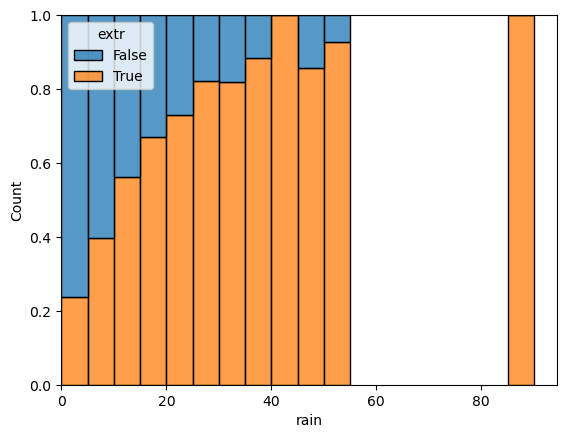

In [39]:
df_ = ds_out[['predictions','rain']].to_dataframe()
df_['extr'] = df_.predictions>0.5

import seaborn.objects as so 
import seaborn as sns
sns.histplot(df_, x='rain', hue='extr', multiple='fill', bins=np.arange(0,100,5))


In [ ]:
all_preds_train = []
all_targets_train = []
all_preds_val = []
all_targets_val = []
all_preds_test = []
all_targets_test = []

with torch.no_grad():
    for x, y in tqdm(dataloader.train_loader):
        x = x.to('cpu', non_blocking=True)
        y = y.to('cpu', non_blocking=True)
        preds = torch.sigmoid(lightning_model(x))
        all_preds_train.append(preds)
        all_targets_train.append(y)

    for x, y in tqdm(dataloader.val_loader):
        x = x.to('cpu', non_blocking=True)
        y = y.to('cpu', non_blocking=True)
        preds = torch.sigmoid(lightning_model(x))
        all_preds_val.append(preds)
        all_targets_val.append(y)

    for x, y in tqdm(dataloader.test_loader):
        x = x.to('cpu', non_blocking=True)
        y = y.to('cpu', non_blocking=True)
        preds = torch.sigmoid(lightning_model(x))
        all_preds_test.append(preds)
        all_targets_test.append(y)



preds_train = torch.cat(all_preds_train).cpu().numpy()
targets_train = torch.cat(all_targets_train).cpu().numpy()

preds_val = torch.cat(all_preds_val).cpu().numpy()
targets_val = torch.cat(all_targets_val).cpu().numpy()

preds_test = torch.cat(all_preds_test).cpu().numpy()
targets_test = torch.cat(all_targets_test).cpu().numpy()

targets_train[targets_train<1] = 0
targets_val[targets_val<1] = 0
targets_test[targets_test<1] = 0

100%|██████████| 18/18 [01:33<00:00,  5.19s/it]


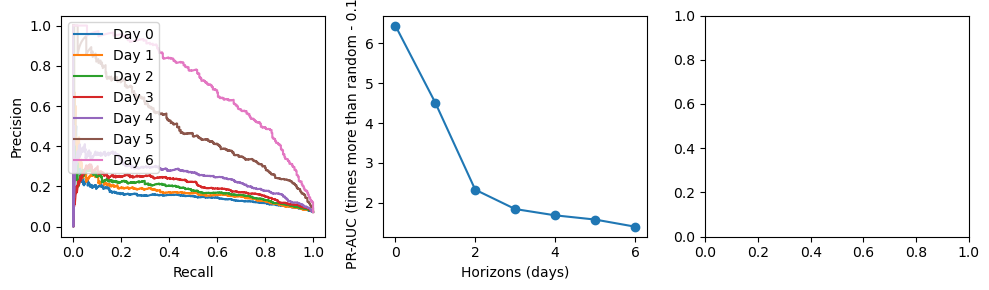

In [17]:
from sklearn.metrics import f1_score

from sklearn.metrics import precision_recall_curve, average_precision_score
fig, axs = plt.subplots(1,3,figsize=(10,3))
aps=[]
for k in range(7):
    targets = targets_test[:,6-k]
    predictions = preds_test[:,6-k]
    aps.append(average_precision_score(targets, predictions, pos_label=1)/.11)
    prec, recall, thresholds = precision_recall_curve(targets, predictions, pos_label=1)
    axs[0].plot(recall, prec, label=f'Day {k}')
axs[0].set_xlabel('Recall')
axs[0].set_ylabel('Precision')
axs[0].legend()

axs[1].plot(np.arange(6,-1,-1),aps, marker='o')
axs[1].set_ylabel('PR-AUC (times more than random - 0.11)')
axs[1].set_xlabel('Horizons (days)')


plt.tight_layout()

In [11]:
targets_test

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(4608, 7))

In [41]:
time ='2011-11-25'
input_tensor = torch.Tensor(ds_out.features.sel(time_of_event=time).values)[:1]
model = lightning_model.model

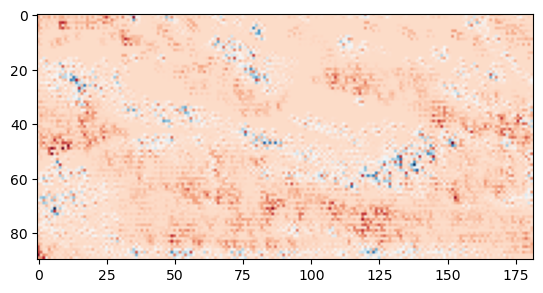

In [42]:
from pytorch_grad_cam import GuidedBackpropReLUModel
from pytorch_grad_cam.utils.image import (
    show_cam_on_image, deprocess_image, preprocess_image
)
model = lightning_model.model
gb_model = GuidedBackpropReLUModel(model=model, device='cpu')

time = '2005-01-04'
input_tensor = torch.Tensor(ds_out.features.sel(time_of_event=time).values)[:1]
gb = gb_model(input_tensor, target_category=6)
plt.imshow(gb.sum(axis=2), cmap='RdBu')

In [43]:
for m in model.modules():
    # for n in m.modules():
        print(m)

CNN_MLP(
  (CNN): Encoder(
    (convblock0): DownBlock(
      (feat): SingleConv(
        (block): Sequential(
          (0): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout2d(p=0.2, inplace=False)
        )
      )
      (down): Downsample(
        (op): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
      )
    )
    (convblock1): DownBlock(
      (feat): SingleConv(
        (block): Sequential(
          (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout2d(p=0.2, inplace=False)
        )
      )
      (down): Downsample(
        (op): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
      )
    )
    (

In [34]:
attach_lrp_rules(model)  # ← important


for n,m in model.named_modules():
    if hasattr(m,"rule"):
        print(n, type(m), m.rule)

CNN.convblock0.feat.block.0 <class 'torch.nn.modules.conv.Conv2d'> <captum.attr._utils.lrp_rules.EpsilonRule object at 0x7fa7e05a71a0>
CNN.convblock0.feat.block.1 <class 'torch.nn.modules.batchnorm.BatchNorm2d'> <captum.attr._utils.lrp_rules.IdentityRule object at 0x7fa7e05a5550>
CNN.convblock0.feat.block.2 <class 'torch.nn.modules.activation.ReLU'> <captum.attr._utils.lrp_rules.IdentityRule object at 0x7fa7e06c3ce0>
CNN.convblock0.feat.block.3 <class 'torch.nn.modules.dropout.Dropout2d'> <captum.attr._utils.lrp_rules.IdentityRule object at 0x7fa7e05a52b0>
CNN.convblock0.feat.block.4 <class 'torch.nn.modules.conv.Conv2d'> <captum.attr._utils.lrp_rules.EpsilonRule object at 0x7fa7e05a4f80>
CNN.convblock0.feat.block.5 <class 'torch.nn.modules.batchnorm.BatchNorm2d'> <captum.attr._utils.lrp_rules.IdentityRule object at 0x7fa7e05a44a0>
CNN.convblock0.feat.block.6 <class 'torch.nn.modules.activation.ReLU'> <captum.attr._utils.lrp_rules.IdentityRule object at 0x7fa7e05a6fc0>
CNN.convblock0.d

In [46]:
from captum.attr._utils.lrp_rules import EpsilonRule, GammaRule, IdentityRule
import torch.nn as nn

def find_missing_rule(mod):
    for name, m in mod.named_modules():
        if not hasattr(m, "rule") or m.rule is None:
            print("Missing rule:", name, type(m))
            return name, m
    print("All modules have a rule!")
    return None, None

_ = find_missing_rule(model)

Missing rule:  <class 'ml_module_rain.models.neuralnetworks.CNN_MLP'>


In [45]:
from captum.attr import LRP
from captum.attr._utils.lrp_rules import EpsilonRule, GammaRule, IdentityRule
from torch import nn

time ='2011-11-25'
input_tensor = torch.Tensor(ds_out.features.sel(time_of_event=time).values)[:1]
model = lightning_model.model


def attach_lrp_rules(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            m.rule = EpsilonRule(1e-6)      # stable default
        elif isinstance(m, (nn.ReLU, nn.MaxPool2d, nn.AvgPool2d, nn.Dropout, nn.Identity)):
            m.rule = IdentityRule()
        elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm, nn.LayerNorm)):
            # Often use Identity; if unstable, try EpsilonRule.
            m.rule = IdentityRule()
        elif isinstance(m, (nn.Dropout2d)):
            # Often use Identity; if unstable, try EpsilonRule.
            m.rule = IdentityRule()
        elif isinstance(m, GlobalAvgPool):
            m.rule = IdentityRule()

def split_shared_relus(model):
    for name, m in list(model.named_children()):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            m.rule = EpsilonRule(1e-6)      # stable default
        elif isinstance(m, (nn.ReLU, nn.MaxPool2d, nn.AvgPool2d, nn.Dropout, nn.Identity)):
            m.rule = IdentityRule()
        elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm, nn.LayerNorm)):
            # Often use Identity; if unstable, try EpsilonRule.
            m.rule = IdentityRule()
        elif isinstance(m, (nn.Dropout2d)):
            # Often use Identity; if unstable, try EpsilonRule.
            m.rule = IdentityRule()
        elif isinstance(m, GlobalAvgPool):
            m.rule = IdentityRule()
        if isinstance(m, nn.ReLU):
            # replace with a fresh copy
            setattr(m, name, nn.ReLU(inplace=False))
            m.rule = IdentityRule()
        else:
            split_shared_relus(m)


from captum.attr import LRP
model = lightning_model.model
model.eval()

model.eval()
# attach_lrp_rules(model)  # ← important
# split_shared_relus(model)

# attach_lrp_rules(model) 
lrp = LRP(model)
# x: (B, C, H, W) preprocessed like training
attr = lrp.attribute(input_tensor, target=6)  

AttributeError: 'NoneType' object has no attribute 'relevance_input'

In [ ]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputSoftmaxTarget
from pytorch_grad_cam.metrics.cam_mult_image import CamMultImageConfidenceChange
# Create the metric target, often the confidence drop in a score of some category
metric_target = ClassifierOutputSoftmaxTarget(281)
scores, batch_visualizations = CamMultImageConfidenceChange()(input_tensor, 
  inverse_cams, targets, model, return_visualization=True)
visualization = deprocess_image(batch_visualizations[0, :])

# State of the art metric: Remove and Debias
from pytorch_grad_cam.metrics.road import ROADMostRelevantFirst, ROADLeastRelevantFirst
cam_metric = ROADMostRelevantFirst(percentile=75)
scores, perturbation_visualizations = cam_metric(input_tensor, 
  grayscale_cams, targets, model, return_visualization=True)

# You can also average across different percentiles, and combine
# (LeastRelevantFirst - MostRelevantFirst) / 2
from pytorch_grad_cam.metrics.road import ROADMostRelevantFirstAverage,
                                          ROADLeastRelevantFirstAverage,
                                          ROADCombined
cam_metric = ROADCombined(percentiles=[20, 40, 60, 80])
scores = cam_metric(input_tensor, grayscale_cams, targets, model)

In [13]:
import cv2
cam_mask = cv2.merge([grayscale_cam, grayscale_cam, grayscale_cam])
cam_gb = deprocess_image(cam_mask * gb)
result = deprocess_image(gb)

NameError: name 'grayscale_cam' is not defined

In [48]:
from captum.attr import IntegratedGradients, NoiseTunnel

model = lightning_model.model
model.eval()

ig = IntegratedGradients(model)
nt = NoiseTunnel(ig)
steps=7
time = '2005-01-04'


tensor_in = torch.Tensor(ds_out.features.sel(time_of_event=time).values)
x_in = torch.Tensor(ds_out.features.sel(time_of_event=time).values).requires_grad_()  # shape: (timestep_past, var_name, lat, lon)
baseline = torch.zeros_like(x_in)

In [49]:
attrs_ig = ig.attribute(
    x_in,  # add batch dim if model expects it
    baselines=baseline,
    target=[steps - 1 -k for k in range(0,steps)]
)

attrs_cpu_ig = attrs_ig.detach().cpu()  # remove batch dim

# Rebuild DataArray
da_attrs_ig = xr.DataArray(
    attrs_cpu_ig,
    dims=['timestep_past', 'var_name', 'latitude', 'longitude'],
    coords=dict(
        timestep_past=ds_out.timestep_past,
        var_name=ds_out.var_name,
        latitude=ds_out.latitude,
        longitude=ds_out.longitude
    )
)

In [115]:
attrs_nt = nt.attribute(
    x_in,  # add batch dim if model expects it
    baselines=baseline,
    target=[steps - 1 -k for k in range(0,steps)]
)

attrs_cpu_nt = attrs_nt.detach().cpu()  # remove batch dim

# Rebuild DataArray
da_attrs_nt = xr.DataArray(
    attrs_cpu_nt,
    dims=['timestep_past', 'var_name', 'latitude', 'longitude'],
    coords=dict(
        timestep_past=ds_out.timestep_past,
        var_name=ds_out.var_name,
        latitude=ds_out.latitude,
        longitude=ds_out.longitude
    )
)

In [51]:

ds_cycs = xr.open_dataset("/Data/gfi/users/rogui7909/data/NN_outputs/attributions/hsrny3md_attributions_all.nc").distance_to_cyclone



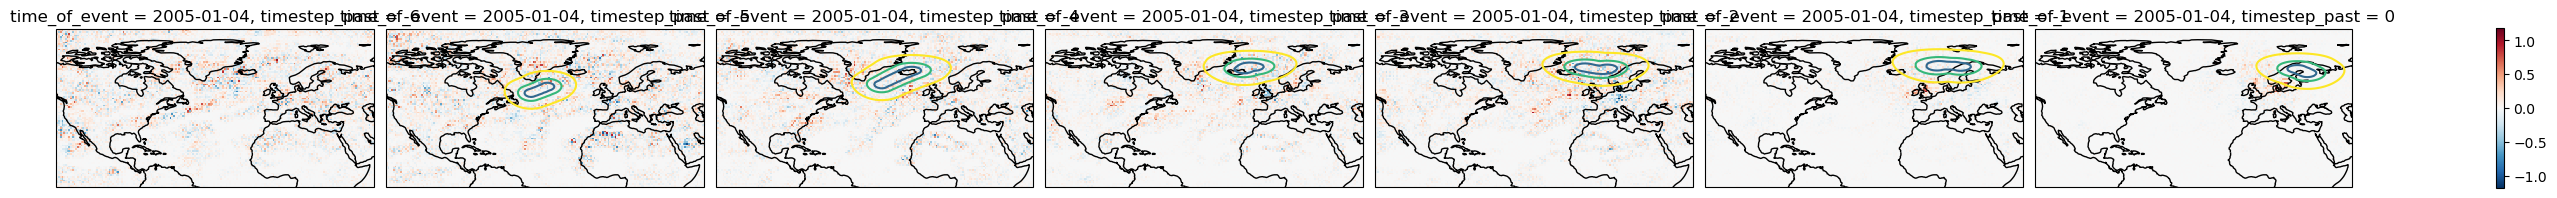

In [52]:
da_attrs_ig_sum = da_attrs_ig.sum('var_name')
plot = (da_attrs_ig_sum /da_attrs_ig_sum .max(['longitude','latitude'])).plot(col='timestep_past',
                                                                                subplot_kws = dict(projection=ccrs.PlateCarree()),
                                                                                transform = ccrs.PlateCarree(), aspect=2, size=2)
for k, ax in enumerate(plot.axs.flatten()):
    ds_cycs.sel(time_of_event=time).isel(timestep_past=k%7).plot.contour(ax=ax, levels=[0,250,500,1000], transform=ccrs.PlateCarree())
    ax.coastlines()

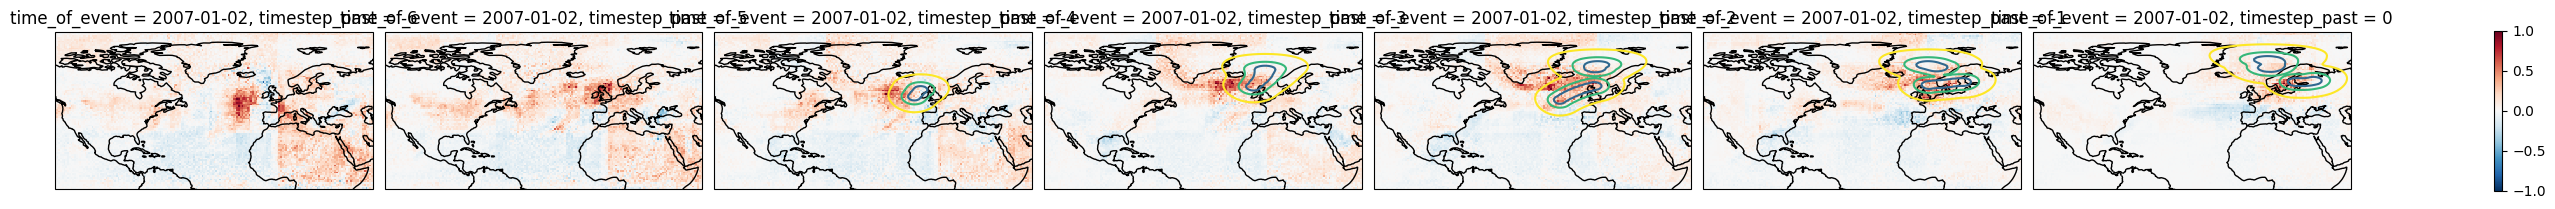

In [120]:
da_attrs_nt_sum = da_attrs_nt.sum('var_name')
plot = (da_attrs_nt_sum /da_attrs_nt_sum .max(['longitude','latitude'])).plot(col='timestep_past',
                                                                                subplot_kws = dict(projection=ccrs.PlateCarree()),
                                                                                transform = ccrs.PlateCarree(), aspect=2, size=2)
for k, ax in enumerate(plot.axs.flatten()):
    ds_cycs.sel(time_of_event=time).isel(timestep_past=k%7).plot.contour(ax=ax, levels=[0,250,500,1000], transform=ccrs.PlateCarree())
    ax.coastlines()